All libraries loaded!
Shape: (1256, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
                                 Open        High         Low       Close  \
Date                                                                        
2021-04-26 00:00:00-04:00  131.323815  131.547830  130.086836  131.216675   
2021-04-27 00:00:00-04:00  131.499136  131.888743  130.622546  130.895264   
2021-04-28 00:00:00-04:00  130.817351  131.508895  129.619341  130.106339   
2021-04-29 00:00:00-04:00  132.921194  133.505598  129.005727  130.008942   
2021-04-30 00:00:00-04:00  128.353098  130.086809  127.661570  128.041428   

                              Volume  Dividends  Stock Splits  
Date                                                           
2021-04-26 00:00:00-04:00   66905100        0.0           0.0  
2021-04-27 00:00:00-04:00   66015800        0.0           0.0  
2021-04-28 00:00:00-04:00  107760100        0.0           0.0  
2021-04-29 00:00:00-

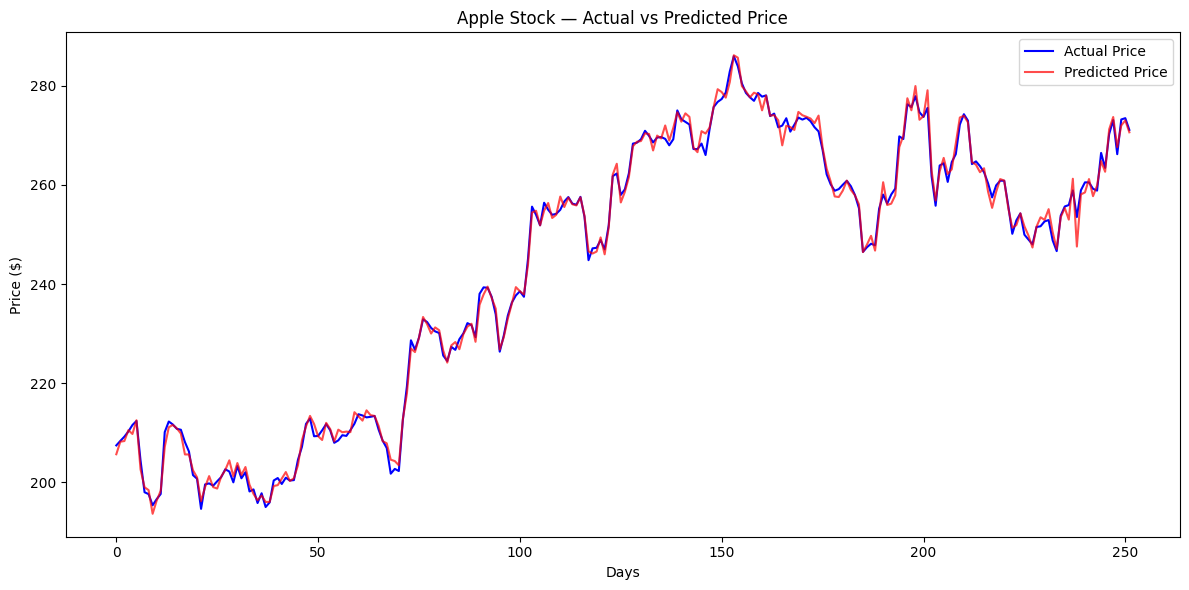

In [1]:

# Task 2: Apple Stock Price Prediction


# Install required libraries
!pip install yfinance scikit-learn

# Import all libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("All libraries loaded!")


# Step 1: Load Apple Stock Data

# Select Apple stock
apple = yf.Ticker("AAPL")

# Get last 5 years data from Yahoo Finance
df = apple.history(period="5y")

# Check data
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
# Step 2: Clean Data


# Keep only useful columns
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

# Check missing values
print("Missing values:")
print(df.isnull().sum())

print("Shape after cleaning:", df.shape)


# Step 3: Prepare Features and Target

# X = input features
# y = target (Close price to predict)
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Split data — keep date order
# 80% training, 20% testing
split = int(len(df) * 0.8)

X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Step 4: Train Linear Regression Model

# Create model
model = LinearRegression()

# Train model on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Check model error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")
print("Lower RMSE = Better model!")

# Step 5: Plot Actual vs Predicted Price

plt.figure(figsize=(12, 6))

# Actual price — blue line
plt.plot(y_test.values,
         color='blue',
         label='Actual Price')

# Predicted price — red line
plt.plot(y_pred,
         color='red',
         label='Predicted Price',
         alpha=0.7)

plt.title('Apple Stock — Actual vs Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()